In [1]:
import numpy as np
import rebound
import sys
sys.path.insert(0,'../model')
from matplotlib.collections import PatchCollection
import mega
import matplotlib.pyplot as plt
from multiprocessing import Pool
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
cm = plt.colormaps['hot_r']

In [2]:
# First, run make.py script to cache the constellation data
#!python make.py

In [164]:
# We run the script in parallel. This part is executed on the worker threads.
worker_sims = None
constellation = None
plot_type = None
Ntime = None
twilight_p = None
def init_worker(_constellation, _plot_type, _Ntime, _twilight_p):
    global worker_sims, constellation, plot_type, Ntime, twilight_p
    constellation = _constellation
    plot_type = _plot_type
    Ntime = _Ntime
    twilight_p = _twilight_p
    worker_sims = {constellation: rebound.Simulation("mega_"+constellation+".bin")}
def getNum(l): 
    latitude=-90+180*l/(Nlat-1)
    row = np.full(Ntime,np.nan)
    for t in range(Ntime):
        hour = 12 + t*24/(Ntime-1)
        hour = (hour if hour<24 else hour-24)
        if plot_type == "solstice":
            month = 9
        elif plot_type == "equinox":
            month = 0
        lon = mega.length_of_night(month,latitude,p=twilight_p)
        if hour <= lon/2 or hour >= 24-lon/2:
            xy, mag = mega.get_stereographic_data(worker_sims, latitude=latitude, month=month, hour=hour, area=800, elevation_cut=10)
            row[t] = np.sum(mag < 5.0)
        
    if constellation=="SXODC":
        row *= 10 # for speed
    return row

In [165]:
def plot(fig, ax, data, title):
    # Plot data
    cb = ax.imshow(data, extent=(0, 24, -90,90), interpolation="nearest", aspect="auto", origin="lower")    
    
    # Labels
    ax.set_xlabel("Solar Time",labelpad=5)
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    
    # Axes
    months = ["noon", "6pm", "midnight", "6am", "noon"]
    ax.set_xticks(np.arange(0.001,25.001,6), labels=months, minor=True)
    ax.tick_params(axis="x",which="major",labelbottom = False,length=0)
    #ax.xaxis.set_ticks(np.arange(0,25,1),minor=True)
    ax.tick_params(axis="x",which="minor",length=4, labelsize=8)
    
    # Grid
    #ax.axhline(90-23.5, color="red", linestyle="--", linewidth=0.8)
    #ax.axhline(-90+23.5, color="red", linestyle="--", linewidth=0.8)
    ax.axhline(0, color="white", linestyle="--", linewidth=0.8)
    ax.axvline(12, color="white", linestyle="--", linewidth=0.8)
    fig.colorbar(cb,label="visible satellites V<5")
    return cb


In [166]:
Ntime, Nlat = 160,160
#constellations = ["Stampede"]
constellations = ["SXODC", "Sunrise", "Stampede"]
data_solstice = globals().get("data_solstice", {})
for constellation in constellations:
    with Pool(processes=80, initializer=init_worker, initargs=(constellation,"solstice",Ntime,6)) as p:
        data_solstice[constellation] = np.array(p.map(getNum, range(Nlat)))

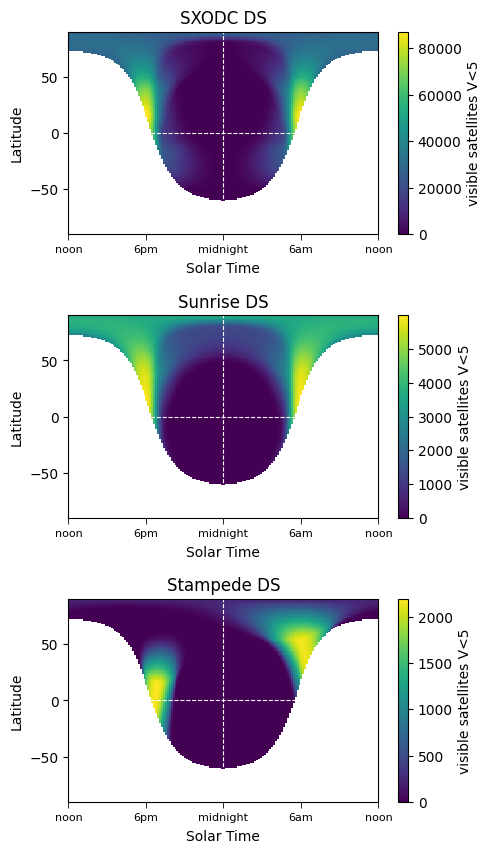

In [167]:
fig, axs = plt.subplots(len(constellations),figsize=(5,10))
plt.subplots_adjust(hspace=0.4)
for i, constellation in enumerate(constellations):
    cb = plot(fig,axs[i],data_solstice[constellation],constellation+" DS")    
fig.savefig("lat-time-ds.png")

In [ ]:
Ntime, Nlat = 160,160
#constellations = ["Stampede"]
constellations = ["SXODC", "Sunrise", "Stampede"]
data_equinox = globals().get("data_equinox", {})
for constellation in constellations:
    with Pool(processes=80, initializer=init_worker, initargs=(constellation,"equinox",Ntime,6)) as p:
        data_equinox[constellation] = np.array(p.map(getNum, range(Nlat)))

In [ ]:
fig, axs = plt.subplots(len(constellations),figsize=(5,10))
plt.subplots_adjust(hspace=0.4)
for i, constellation in enumerate(constellations):
    cb = plot(fig,axs[i],data_equinox[constellation],constellation+" EQ")    
fig.savefig("lat-time-eq.png")